In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/cleaned_online_retail.csv"
)

In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [4]:
df["InvoiceDate"].max()

Timestamp('2023-12-09 12:50:00')

In [5]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2023-12-10 12:50:00')

In [6]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":
        lambda x:
        (snapshot_date - x.max()).days,

    "InvoiceNo":
        "nunique",

    "Revenue":
        "sum"
})

In [7]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [8]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
rfm.shape

(4338, 3)

In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [11]:
df["InvoiceDate"].max()

snapshot_date

rfm.head()

rfm.shape

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


Recency Distribution

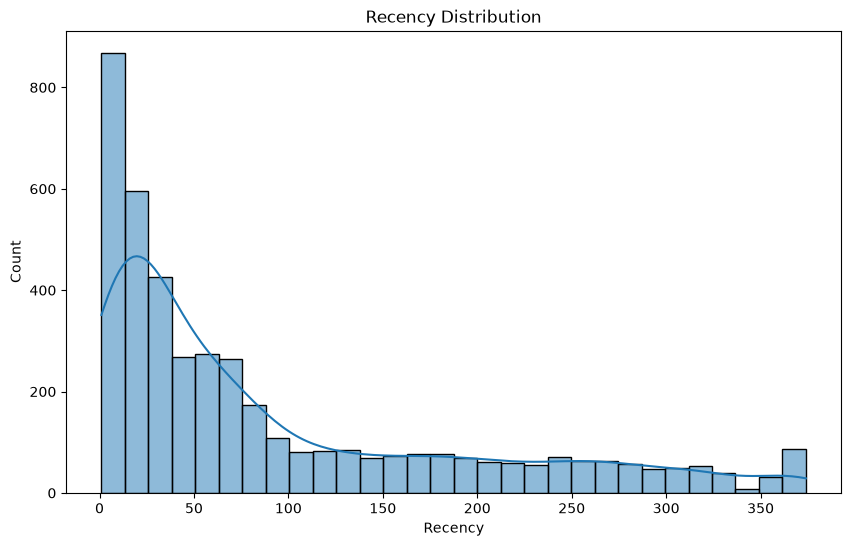

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    rfm["Recency"],
    bins=30,
    kde=True
)

plt.title("Recency Distribution")

plt.show()

Frequency Distribution

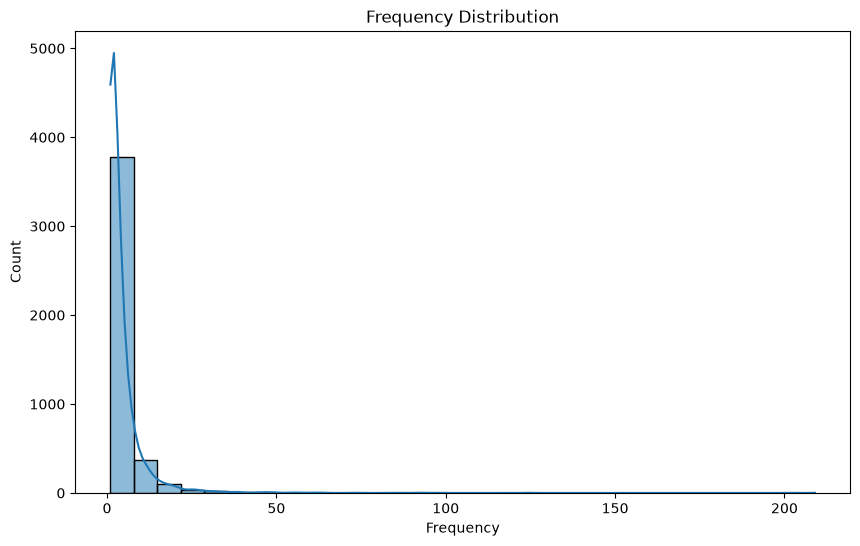

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    rfm["Frequency"],
    bins=30,
    kde=True
)

plt.title("Frequency Distribution")

plt.show()

Monetary Distribution

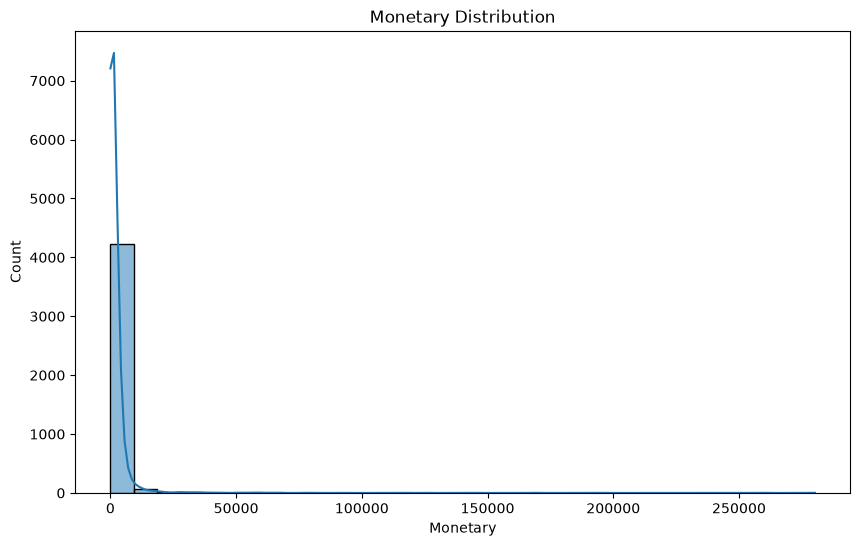

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    rfm["Monetary"],
    bins=30,
    kde=True
)

plt.title("Monetary Distribution")

plt.show()

Boxplots

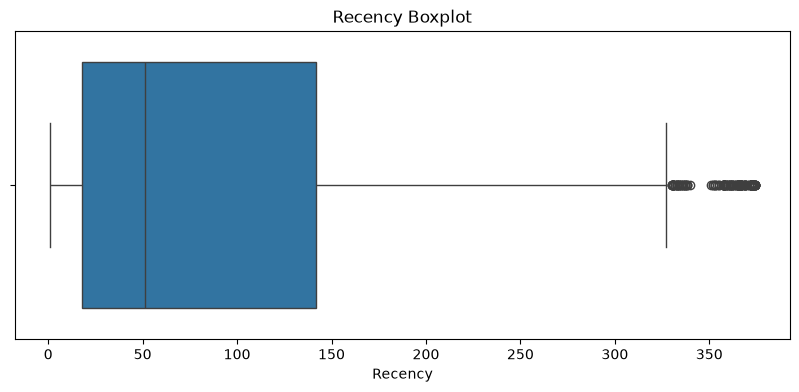

In [15]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=rfm["Recency"]
)

plt.title("Recency Boxplot")

plt.show()

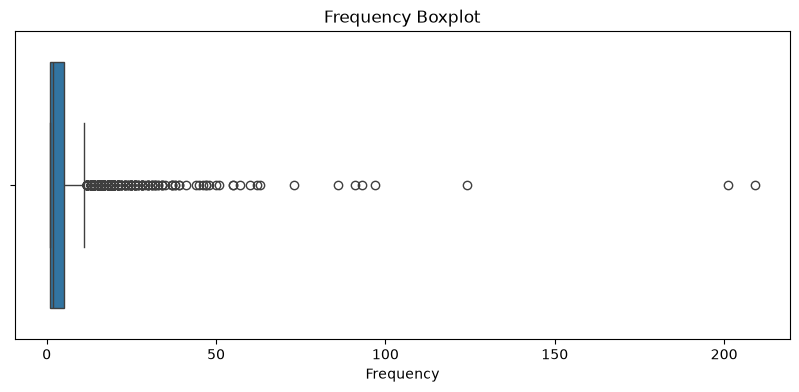

In [16]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=rfm["Frequency"]
)

plt.title("Frequency Boxplot")

plt.show()

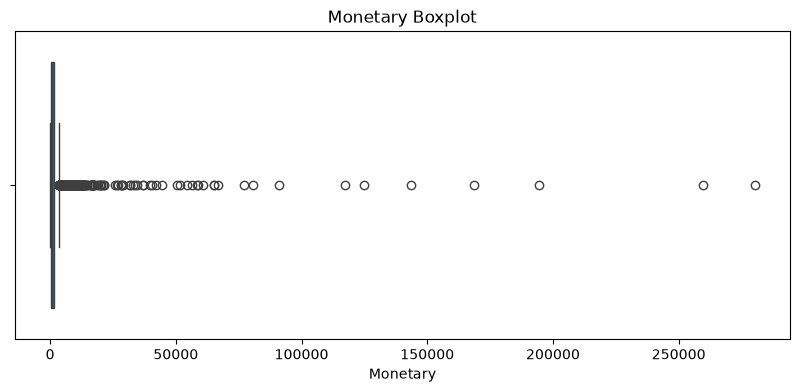

In [17]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=rfm["Monetary"]
)

plt.title("Monetary Boxplot")

plt.show()

Correlation Analysis

In [18]:
rfm.corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.260578,-0.121831
Frequency,-0.260578,1.000000,0.552780
Monetary,-0.121831,0.552780,1.000000


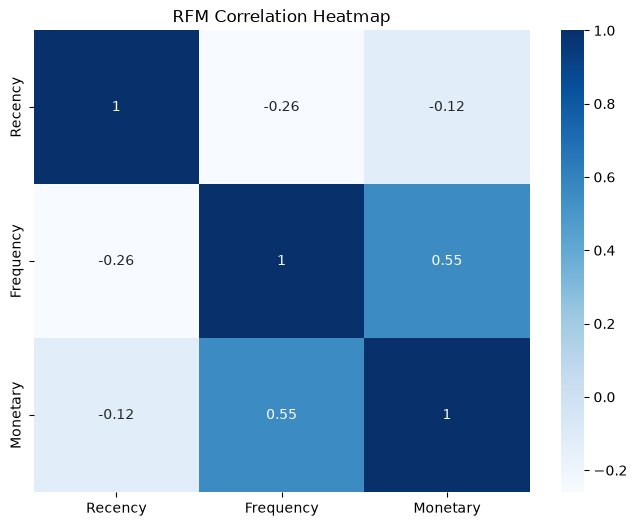

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("RFM Correlation Heatmap")

plt.show()